# Simulação Computacional: Energia e Potência

Neste experimento, avaliamos e classificamos dois sinais distintos com base no seu conteúdo energético e potência média:

1. **Sinal de Energia (Pulso Transitório):** Um sinal de suporte finito, simulando um surto de tensão que se dissipa rapidamente. A sua energia total é finita ($0 < E < \infty$) e a sua potência média tende a zero.
2. **Sinal de Potência (Senoide da Rede Elétrica):** Um sinal periódico que se estende infinitamente, simulando a tensão da rede ($179{,}6\,\text{V}$). A sua energia total tende ao infinito, mas a sua potência média distribuída no tempo é constante ($0 < P < \infty$).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Configuração de estilo acadêmico
sns.set_theme(
    context="paper", style="ticks", palette="colorblind", font="serif",
    rc={
        "font.size": 11, "axes.titlesize": 12, "axes.labelsize": 11,
        "axes.grid": True, "grid.linestyle": "--", "grid.alpha": 0.6,
        "figure.dpi": 120, "savefig.dpi": 300, "savefig.bbox": "tight",
        "mathtext.fontset": "cm",
    },
)

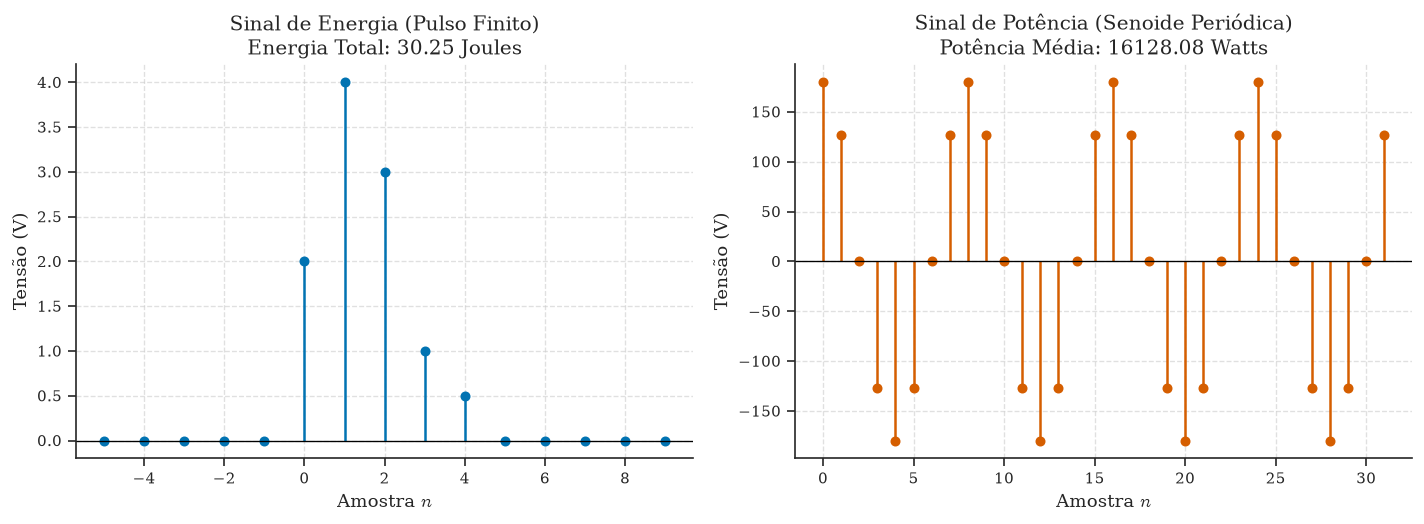

In [2]:
# 1. Sinal de Energia: Pulso Transitório (Suporte Finito)
n_energia = np.arange(-5, 10)
x_energia = np.zeros_like(n_energia, dtype=float)
# Valores do pulso em n = 0, 1, 2, 3, 4
valores_pulso = [2.0, 4.0, 3.0, 1.0, 0.5]
for i, val in enumerate(valores_pulso):
    x_energia[n_energia == i] = val

# Cálculo numérico (Energia)
# E = soma(|x[n]|^2)
energia_pulso = np.sum(x_energia**2)
potencia_pulso = 0.0 # Teórica, pois para N -> infinito, P = E / inf = 0

# 2. Sinal de Potência: Senoide da Rede (Periódico)
# Para analisar a potência, criamos uma janela longa (vários ciclos)
# A = 179.6 V, w0 = pi/4 (8 amostras por ciclo)
N_ciclos = 10
amostras_por_ciclo = 8
N_total = N_ciclos * amostras_por_ciclo
n_potencia = np.arange(0, N_total)

A = 179.6
w0 = np.pi / 4
x_potencia = A * np.cos(w0 * n_potencia)

# Cálculo numérico (Potência Média em uma janela de observação múltipla do período)
# P = (1/N_total) * soma(|x[n]|^2)
potencia_senoide = np.mean(x_potencia**2) 
energia_senoide = np.inf # Teórica, pois a soma infinita diverge

# Plotagem Comparativa
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
cores = sns.color_palette("colorblind")

# Gráfico 1: Sinal de Energia
markerline1, stemlines1, baseline1 = axes[0].stem(
    n_energia, x_energia, linefmt="-", markerfmt="o", basefmt=" "
)
plt.setp(stemlines1, color=cores[0], linewidth=1.5)
plt.setp(markerline1, color=cores[0], markersize=5)
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_title(f"Sinal de Energia (Pulso Finito)\nEnergia Total: {energia_pulso:.2f} Joules")
axes[0].set_ylabel("Tensão (V)")
axes[0].set_xlabel(r"Amostra $n$")

# Gráfico 2: Sinal de Potência
markerline2, stemlines2, baseline2 = axes[1].stem(
    n_potencia[:32], x_potencia[:32], linefmt="-", markerfmt="o", basefmt=" " # Mostrando apenas 4 ciclos para clareza
)
plt.setp(stemlines2, color=cores[3], linewidth=1.5)
plt.setp(markerline2, color=cores[3], markersize=5)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title(f"Sinal de Potência (Senoide Periódica)\nPotência Média: {potencia_senoide:.2f} Watts")
axes[1].set_ylabel("Tensão (V)")
axes[1].set_xlabel(r"Amostra $n$")

sns.despine(trim=False)
fig.tight_layout()

# Salvamento
os.makedirs(".", exist_ok=True)
fig.savefig("grafico_energia_potencia.png")
plt.show()

In [ ]:
print("=== VERIFICAÇÃO NUMÉRICA VS ANALÍTICA ===")
print("\n1. SINAL DE ENERGIA (Pulso):")
energia_teorica = 2**2 + 4**2 + 3**2 + 1**2 + 0.5**2
print(f"Energia Calculada Analiticamente: {energia_teorica:.2f}")
print(f"Energia Verificada no Código    : {energia_pulso:.2f}")
print(f"Potência Média (N -> infinito)  : 0.00")

print("\n2. SINAL DE POTÊNCIA (Senoide Rede):")
potencia_teorica = (A**2) / 2
print(f"Potência Calculada Analiticamente: {potencia_teorica:.2f}")
print(f"Potência Verificada no Código    : {potencia_senoide:.2f}")
print(f"Energia Total (N -> infinito)    : Infinita (Diverge)")

=== VERIFICAÇÃO NUMÉRICA VS ANALÍTICA ===

1. SINAL DE ENERGIA (Pulso):
Energia Calculada Analiticamente: 30.25
Energia Verificada no Código    : 30.25
Potência Média (N -> infinito)  : 0.00

2. SINAL DE POTÊNCIA (Senoide Rede):
Potência Calculada Analiticamente: 16128.08
Potência Verificada no Código    : 16128.08
Energia Total (N -> infinito)    : Infinita (Diverge)
